# Application: Obliquity Pacing of Pleistocene Ice Ages

In this lab we will apply hypothesis testing to evaluate whether obliquity might be pacing the Pleistocene Ice Ages.
This lab broadly follows <a href="https://doi.org/10.1038/nature03401">Huybers and Wunsch (2004)</a>. 

Since the data from that paper is not available, we will use a slightly different dataset and technique. Ideally, the result of our hypothesis test should not be too sensitive to small methodological differences. 

In [2]:
%reset 
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy import optimize
import numpy as np

params = {'legend.fontsize': 'x-large',
          'figure.figsize': (15, 5),
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large'}
plt.rcParams.update(params)

Once deleted, variables cannot be recovered. Proceed (y/[n])?  y


We'll use the Lisiecky and Raymo stack of sediment $\delta^{18}O$ measurements, which is representative of ice volume during the Pleistocene Ice Ages. 


Termination ages following hallowed paleoclimate tradition, we identify glacial terminations by hand



In [6]:
# Let's load the data and take a look at it
df_LR04   =pd.read_csv("LR04.csv");        # Lisieckiy and Raymo 2004 Stack
age=df_LR04['age']
d18=df_LR04['d18O']

FileNotFoundError: [Errno 2] No such file or directory: 'LR04.csv'

NameError: name 'age' is not defined

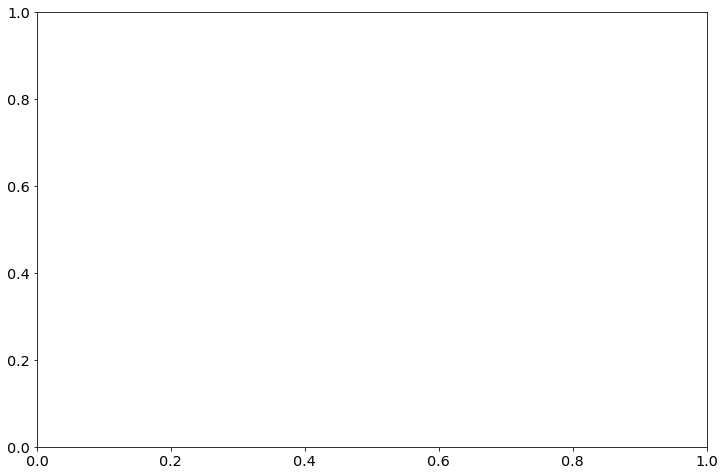

In [4]:
fig,ax=plt.subplots(1,1,figsize=[12,8])
ax.plot(age,-d18,'k')
ax.set_ylabel('$-\delta^{18}O$');
ax.set_xticks([])


In [ ]:


# Load orbital solutoins
df_orbital=pd.read_csv("data/orbital.csv");     # Orbital solutions (Berger 91)


orb_age=-df_orbital['age']
obliq  =df_orbital['obliquity']


# Termination ages following hallowed paleoclimate tradition, we identify glacial terminations by hand
terminations=np.asarray([622, 535, 423, 336, 244, 220, 132, 13])
terminations_d18=df_LR04[df_LR04['age'].isin(terminations)].d18O


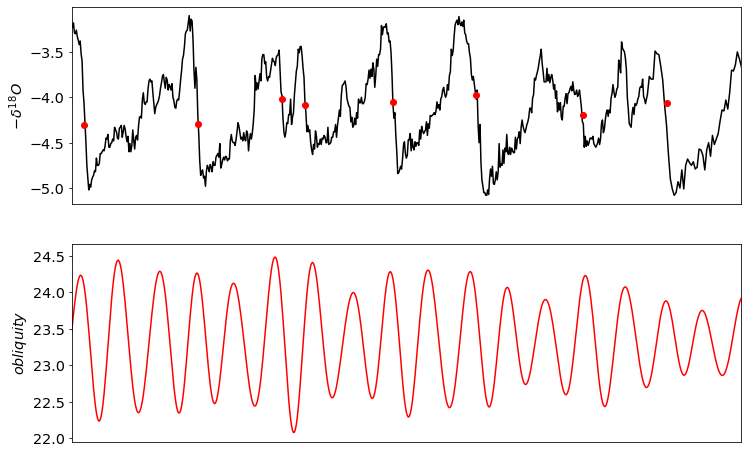

In [453]:
### Let's took a look at the data 
fig,ax=plt.subplots(2,1,figsize=[12,8])
ax[0].plot(age,-d18,'k')
ax[0].set_ylabel('$-\delta^{18}O$');
ax[0].set_xticks([])
#ax[0].set_ylim(bottom=-1.1,top=1.1)

# plot terminations
ax[0].plot(terminations,-terminations_d18,'ro')

ax[1].plot(orb_age,obliq,'r')
ax[1].set_ylabel('$obliquity$');
ax[1].set_xticks([])

for j in range(2):
    ax[j].set_xlim(left=0,right=700)

In [412]:
#Compute phase of obliquity:
t0=42
period=41
time=t0+np.arange(period)

def normalize(y):
    return (y-np.mean(y))/(np.max(y)-np.min(y))*2

def y_hat(phi):
    period=41
    return np.cos(2*np.pi*np.arange(period)/period+phi*np.pi/180)

(42.0, 84.0)

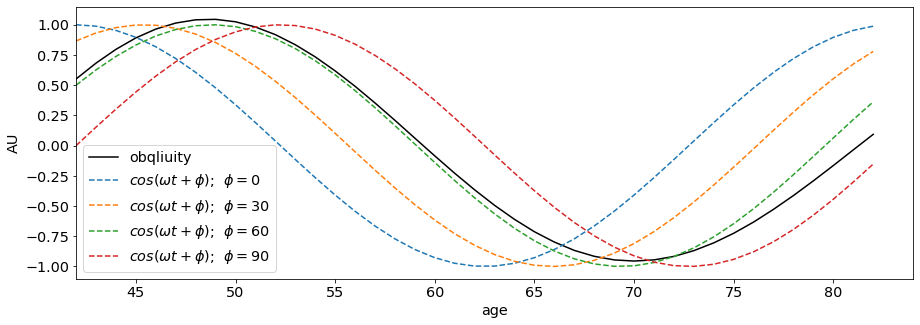

In [413]:
fig,ax=plt.subplots(1,1)
ax.plot(time,normalize(obliq[time]),'k',label='obqliuity')

ax.plot(time,y_hat(phi=0),'--',label='$cos(\omega t +\phi)$;  $\phi=0$')
ax.plot(time,y_hat(phi=-30),'--',label='$cos(\omega t +\phi)$;  $\phi=30$')
ax.plot(time,y_hat(phi=-60),'--',label='$cos(\omega t +\phi)$;  $\phi=60$')
ax.plot(time,y_hat(phi=-90),'--',label='$cos(\omega t +\phi)$;  $\phi=90$')
#ax.vlines(t0,-1,1,'k')
ax.legend();
ax.set_xlabel('age')
ax.set_ylabel('AU')
ax.set_xlim(left=t0)

In [142]:
# compute phase
def J_cost(phi,y):
    res=np.sum((normalize(y)-y_hat(phi))**2)
    return res

obliq_phase=np.zeros(700)
t0=np.arange(700)

for j in np.arange(700):
    time=t0[j]+np.arange(41)
    y=obliq[j:j+41]
    out=optimize.least_squares(J_cost,0,args=[y]);
    obliq_phase[j]=out.x[0]

In [149]:
terminations=np.asarray([623, 535, 423, 336, 243, 220, 132, 13])


phi_obliq_terms    =obliq_phase[np.asarray(terminations)]*np.pi/180
phi_obliq_terms_deg=obliq_phase[np.asarray(terminations)]
R_obliq=1/8*np.abs(np.sum(np.cos(phi_obliq_terms)+1j*np.sin(phi_obliq_terms)))
print(R_obliq)


0.7268582475959839


In [147]:
print(phi_obliq_terms_deg)


[ 24.14427194 -20.39940887  61.97710828  36.22355503 -81.79138917
  72.71964917  21.58603364  43.18849435]


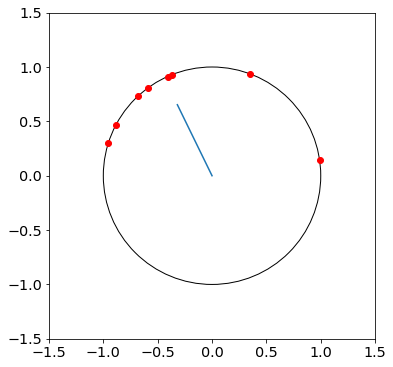

In [189]:
fig, ax = plt.subplots(1,1,figsize=[6,6])
circle = plt.Circle(( 0 , 0 ), radius=1,facecolor='None' ,edgecolor='k')
ax.set_aspect( 1 )
ax.set_xlim(left=-1.5,right=1.5)
ax.set_ylim(bottom=-1.5,top=1.5)
ax.add_artist(circle )

ax.plot(-np.sin(phi_obliq_terms),np.cos(phi_obliq_terms),'ro')

f=R_obliq/np.sqrt(2)
ax.plot([0,-1/8*np.sum(np.sin(phi_obliq_terms))],[0,1/8*np.sum(np.cos(phi_obliq_terms))])



In [306]:
from scipy import stats

def H0(obliq_phase,qprint=False):
    V=np.zeros(700)
    t=699
    T0=90

    terminations=[]
    while t>0:    
        if V[t]<T0:    
            V[t-1]=V[t]+stats.norm.rvs(loc=1,scale=2,size=1)
            t=t-1;        
        elif t>10:
            terminations.append(t)
            V[t-10:t]=np.linspace(0,V[t],10) 
            t=t-10
        else:
            terminations.append(t)
            V[0:t]=np.linspace(0,V[t],10)[-t:] 
            t=0

    np.size(terminations)
    phi_obliq_terms    =obliq_phase[np.asarray(terminations)]*np.pi/180
    R_obliq=1/8*np.abs(np.sum(np.cos(phi_obliq_terms)+1j*np.sin(phi_obliq_terms)))

    if qprint:
        fig, ax = plt.subplots(2,1,figsize=[12,4])
        circle = plt.Circle(( 0 , 0 ), radius=1,facecolor='None' ,edgecolor='k')
        ax[0].set_aspect( 1 )
        ax[0].set_xlim(left=-1.5,right=1.5)
        ax[0].set_ylim(bottom=-1.5,top=1.5)
        ax[0].add_artist(circle )

        ax[0].plot(-np.sin(phi_obliq_terms),np.cos(phi_obliq_terms),'ro')
        ax[0].plot([0,-1/8*np.sum(np.sin(phi_obliq_terms))],[0,1/8*np.sum(np.cos(phi_obliq_terms))])

        ax[1].plot(np.arange(0,700),-V)
        
    return R_obliq


0.6917215849472558

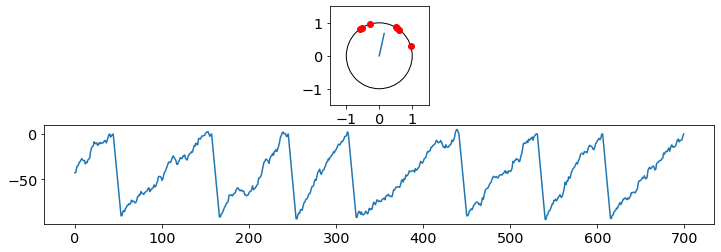

In [345]:
H0(obliq_phase,True)

In [252]:
Ndraws=1000
H0_vec=np.zeros(Ndraws)
for j in range(Ndraws):
    H0_vec[j]=H0(obliq_phase)

KeyboardInterrupt: 

(array([ 21.,  43.,  68.,  80.,  97., 114., 127.,  87.,  84.,  65.,  56.,
         47.,  33.,  26.,  16.,  14.,  11.,   5.,   3.,   3.]),
 array([0.00691776, 0.04457542, 0.08223309, 0.11989075, 0.15754842,
        0.19520608, 0.23286375, 0.27052141, 0.30817907, 0.34583674,
        0.3834944 , 0.42115207, 0.45880973, 0.4964674 , 0.53412506,
        0.57178272, 0.60944039, 0.64709805, 0.68475572, 0.72241338,
        0.76007105]),
 <BarContainer object of 20 artists>)

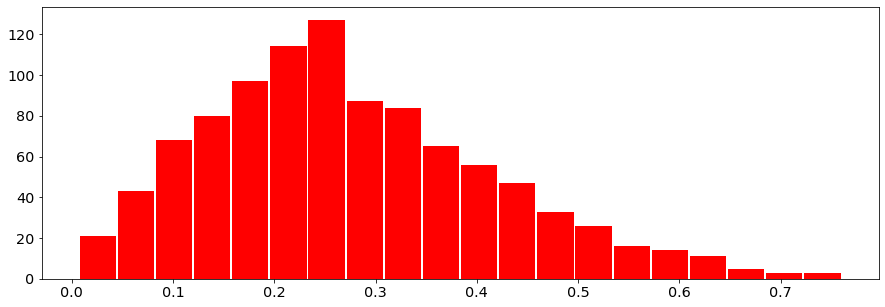

In [223]:
plt.hist(H0_vec,20,rwidth=0.95,color='red')